In [493]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [498]:
#reading data
df = pd.read_csv('./test_data.csv')

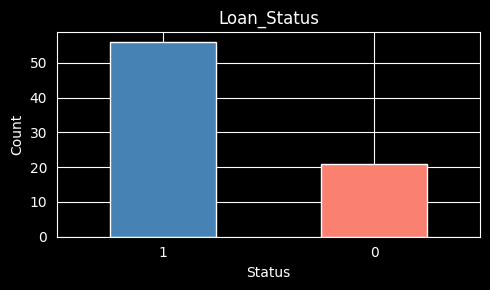

In [522]:
plt.figure(figsize=(5, 3))
df['Loan_Status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Loan_Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [494]:
df.tail()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
72,1,1,2,0,0,8.457231,7.235619,5.017280,5.888878,1.0,1,1,8.715388
73,1,1,2,1,0,8.093768,7.507141,4.406719,5.888878,1.0,2,1,8.535819
74,1,1,2,0,0,8.094684,6.184149,4.912655,5.888878,1.0,1,1,8.232440
75,0,1,0,1,1,8.873888,0.000000,4.934474,5.888878,1.0,0,1,8.873888
76,0,0,0,0,0,7.774436,0.000000,2.302585,5.888878,1.0,2,0,7.774436


In [495]:
def scaling(DataFrame,NumiricalColumns,Scaler):
    #for perpaing data for logistic_regression by shrinking and scaling it to 1s and 0s
    for col in NumiricalColumns:
        DataFrame[col] = np.log1p(DataFrame[col])
    #we will need to drop the result data since droping it will be a pain after scaling the data
    DataFrame = DataFrame.drop('Loan_Status', axis=1)
    DataFrame = Scaler.fit_transform(DataFrame)
    return DataFrame


In [496]:
# a function that replaces null values
def preproccess_data(DataFrame):
    DataFrame=DataFrame.drop('Loan_ID', axis=1)
    #Filling missing values in Catagurical Column using Mode
    DataFrame['Dependents']=DataFrame['Dependents'].fillna(DataFrame['Dependents'].mode()[0])
    DataFrame['Gender']=DataFrame['Gender'].fillna(DataFrame['Gender'].mode()[0])
    DataFrame['Credit_History']=DataFrame["Credit_History"].fillna(DataFrame['Credit_History'].mode()[0])
    DataFrame['Self_Employed']=DataFrame['Self_Employed'].fillna(DataFrame['Self_Employed'].mode()[0])
    #Filling missing values in Numerical Columns using Median to handle Outlier
    DataFrame['Loan_Amount_Term']=DataFrame["Loan_Amount_Term"].fillna(DataFrame['Loan_Amount_Term'].median())

    #solving non-Standard-data in Dependent by replacing them (3+->3,
    # nan->0)  before encoding
    DataFrame['Dependents'] = DataFrame['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
    DataFrame['Dependents'] = pd.to_numeric(DataFrame['Dependents'], errors='coerce').fillna(0).astype(int)
    return DataFrame

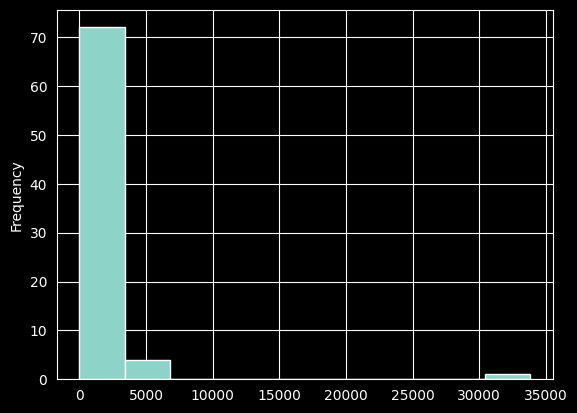

In [499]:
#same but using Plot instead
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

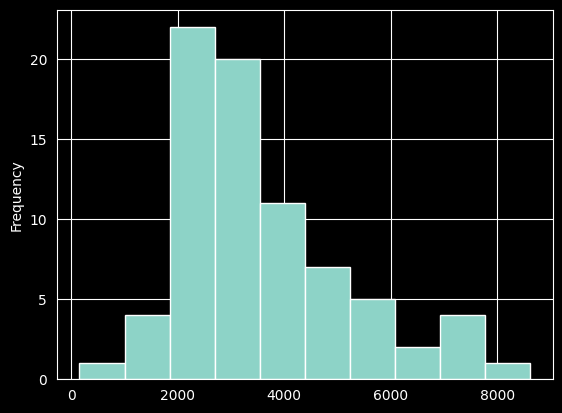

In [500]:
#drawing a Frequancy box blot for applicationIncome
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

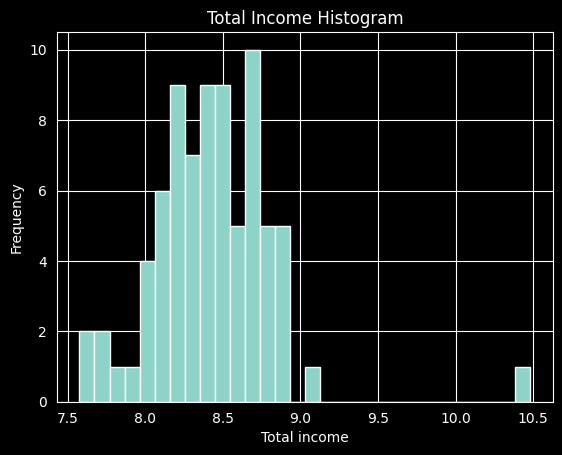

In [508]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

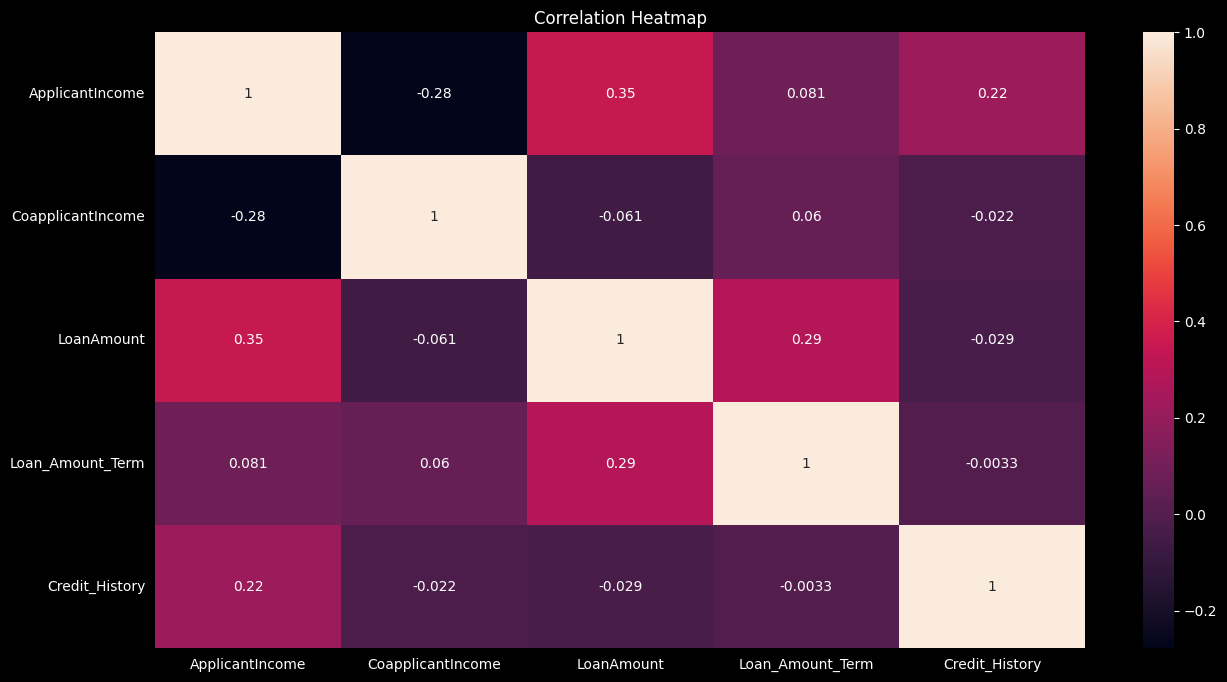

In [501]:
#correlation Heatmap used to know which features have more impact on
#Loan_Status ;turned out that removing or leaving a feature there will not#
#do anything to the accurcy of the rusult so all features are left except
# Loan_ID
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [502]:
#--checking whether our data is biased to one class
print(df['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.727273
N    0.272727
Name: proportion, dtype: float64


In [503]:
#--checking if there were duplicate data
print(df.duplicated().sum())

0


In [504]:
#checking if all data type are numerical so
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [497]:
def EncodingData(DataFrame,Encoder,CataguricalColumns):
      #encoding Categorical Data into numerical ones so we can use it our
      # Model
      for col in CataguricalColumns:
            DataFrame[col] = Encoder.fit_transform(DataFrame[col])

      return DataFrame

In [506]:
#checking null value percentage to determine whether to drop or
#rather fill the missing data
df.isna().sum()/len(df)*100

Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
TotalIncome          0.0
dtype: float64

In [507]:
#checking if nulls are still there
df.isna().sum()/len(df)*100

Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
TotalIncome          0.0
dtype: float64

In [509]:
"""#------Preparing Testing Data
#--Loading testing data
tdf = pd.read_csv("./test_data.csv")
# now lets add TotalIncome to our dataframe
tdf['TotalIncome']=tdf['ApplicantIncome']+tdf['CoapplicantIncome']
#now lets preprocess our data
#Note that we will use the same encoder that we used in our train data as not to change our values
tdf = preproccess_data(tdf)
tdf = EncodingData(tdf,le,categ_cols)
tdf_scaled = scaling(tdf,numirical_cols,scaler)
#Lets see if the data is balanced
print(tdf['Loan_Status'].value_counts(normalize = 'true'))"""

'#------Preparing Testing Data\n#--Loading testing data\ntdf = pd.read_csv("./test_data.csv")\n# now lets add TotalIncome to our dataframe\ntdf[\'TotalIncome\']=tdf[\'ApplicantIncome\']+tdf[\'CoapplicantIncome\']\n#now lets preprocess our data\n#Note that we will use the same encoder that we used in our train data as not to change our values\ntdf = preproccess_data(tdf)\ntdf = EncodingData(tdf,le,categ_cols)\ntdf_scaled = scaling(tdf,numirical_cols,scaler)\n#Lets see if the data is balanced\nprint(tdf[\'Loan_Status\'].value_counts(normalize = \'true\'))'

In [510]:
#it seems that the data is passable lets train our model
#features are the columns that we will use as independant varables in our
# model
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed','Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']
#Expected Result will be the dependant variable in our model the thing we
# want our model to guess in this case it is weather our student received a loan or not
ExpectedResults = 'Loan_Status'

In [505]:
#--adding TotalIncnome to our columns
df['TotalIncome']=df['ApplicantIncome']+df['CoapplicantIncome']
#first we preproccess the data frame to solve nulls and nowanted data in the data frame

df=preproccess_data(df)
#initlizing the Encoder and the catugurical columns that need to be Encoder
# to Numbers so we can use them in our model
categ_cols = [ 'Gender','Married','Dependents','Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
numirical_cols   = ['ApplicantIncome','CoapplicantIncome','TotalIncome','LoanAmount','Loan_Amount_Term']
le = LabelEncoder()
scaler = MinMaxScaler()
#now we Encode the data
df = EncodingData(df,le,categ_cols)
df_scaled = scaling(df,numirical_cols,scaler)

In [511]:
x = df[features]
y = df[ExpectedResults]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [512]:
#we will use diffrent Model to gain diffrent resualt and see the result for each model

#-------Model #1 Gradient Boost Classifer Model
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=1)
model.fit(x_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [513]:
#Now we will use the training data to train and test our model
from sklearn.model_selection import cross_val_score
#cv mean the amount of section we split our model to, ours is 5 sections
#cross_val_score will use 4 parts to train and one part to test the testing
# part change with each Iteration the number of Iteration equal the number
# of sections we defined
scores = cross_val_score(model, x_train, y_train, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.84615385 1.         0.83333333 0.83333333 0.66666667]
Average Accuracy: 0.8358974358974359
Standard Deviation: 0.105533926293624


In [514]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8800


In [515]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc: .4f}")

AUC Score:  0.9167


In [516]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [517]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = rf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")
predictions = rf.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

F1-Score: 0.8800
Model Accuracy: 0.8125


In [518]:
#Evaluating the Model
gb_y_pred = model.predict(x_train)
print(f"Model Accuracy On Its own data  : {accuracy_score(y_train, gb_y_pred)}")
gb_y_pred_test = model.predict(x_test)
print(f"Model Accuracy On Its test Data : {accuracy_score(y_test, gb_y_pred_test)}")

Model Accuracy On Its own data  : 0.8688524590163934
Model Accuracy On Its test Data : 0.8125


In [519]:
"""rf_y_pred = rf.predict(x_train)
print(f"Model Accuracy: {accuracy_score(y_train, rf_y_pred)}")
print(classification_report(y_train, rf_y_pred))"""

'rf_y_pred = rf.predict(x_train)\nprint(f"Model Accuracy: {accuracy_score(y_train, rf_y_pred)}")\nprint(classification_report(y_train, rf_y_pred))'

In [520]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
x_train = df_scaled# all columns except target
y_train = df[ExpectedResults]
x_test = tdf_scaled
y_test = tdf[ExpectedResults]
model = LogisticRegression(class_weight='balanced')
model.fit(x_train, y_train)
model.fit(x_train, y_train)
lr_y_pred = model.predict(x_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, lr_y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_y_pred))

Accuracy: 0.831

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.76      0.71        21
           1       0.91      0.86      0.88        56

    accuracy                           0.83        77
   macro avg       0.79      0.81      0.80        77
weighted avg       0.84      0.83      0.83        77

Confusion Matrix:
[[16  5]
 [ 8 48]]


Text(50.722222222222214, 0.5, 'Actual')

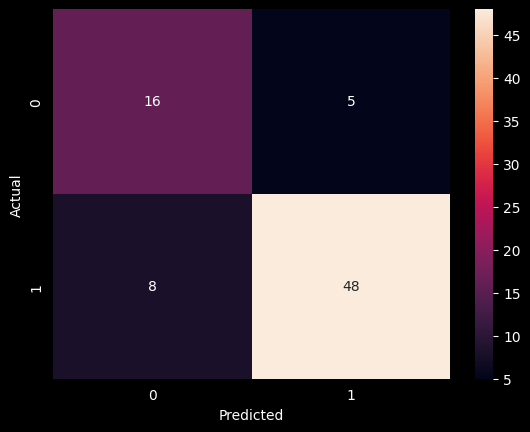

In [521]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')